# Build Dataset — Twitch Network

Three-stage pipeline:
1. **Structural features** — PySpark: loads raw edge list, samples negative edges, computes graph similarity features, writes `data/twitch_structural.csv`
2. **Node attribute enrichment** — enriches structural CSV with 5 pairwise node-attribute features, writes `data/twitch.csv`
3. **Verification** — runs PASS/FAIL checks on the final dataset


In [ ]:
# @title
import networkx as nx
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Twitch Network") \
    .getOrCreate()
df_edges = spark.read.csv("data/musae_ENGB_edges.csv", header=True, inferSchema=True)

FROM_COLUMN = "from"
TO_COLUMN = "to"

G = nx.Graph()
for row in df_edges.select(FROM_COLUMN, TO_COLUMN).toLocalIterator():
    G.add_edge(row[FROM_COLUMN], row[TO_COLUMN])

number_of_edges = G.number_of_edges()

print(f"{'Number of nodes:':<35} {G.number_of_nodes():>10,}")
print(f"{'Number of edges:':<35} {G.number_of_edges():>10,}")
print(f"{'Average clustering coefficient:':<35} {nx.average_clustering(G):>10.4f}")
print(f"{'Number of connected components:':<35} {nx.number_connected_components(G):>10}")

Number of nodes:                         7,126
Number of edges:                        35,324
Average clustering coefficient:         0.1309
Number of connected components:              1


In [ ]:
# @title
non_edges = list(nx.non_edges(G))
print(f"Non-edges length: {len(non_edges)}")

Non-edges length: 25351051


In [ ]:
# @title
# 1. Create negative edge samples by randomly sampling non-connected node pairs.
import random

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
negative_samples = random.sample(non_edges, number_of_edges)

print(f"Negative edge samples length: {len(negative_samples)}")
print(negative_samples[:5])

Negative edge samples length: 35324
[(4332, 5718), (545, 6707), (118, 6637), (6156, 6918), (1443, 1541)]


In [ ]:
# @title
# 2. Combine positive and negative samples into a single Spark DataFrame.
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType

# combine positive samples with label 1 and negative samples with label 0
samples = [(u, v, 1) for u, v in G.edges()] + \
          [(u, v, 0) for u, v in negative_samples]

print(f"Length of samples {len(samples)}")

# create spark data frame
TARGET_COLUMN = "link"

schema = StructType([
    StructField(FROM_COLUMN, IntegerType(), False),
    StructField(TO_COLUMN, IntegerType(), False),
    StructField(TARGET_COLUMN, IntegerType(), False)
])

df_samples = spark.createDataFrame(samples, schema)

df_samples.printSchema()
df_samples.show(5)

Length of samples 70648
root
 |-- from: integer (nullable = false)
 |-- to: integer (nullable = false)
 |-- link: integer (nullable = false)

+----+----+----+
|from|  to|link|
+----+----+----+
|6194| 255|   1|
|6194| 980|   1|
|6194|2992|   1|
|6194|2507|   1|
|6194| 986|   1|
+----+----+----+
only showing top 5 rows


In [ ]:
# @title
# 3. Make sure to shuffle the dataframe.
from pyspark.sql import functions as pysf

df_samples = df_samples.orderBy(pysf.rand(seed=RANDOM_SEED))
df_samples.show(5)

+----+----+----+
|from|  to|link|
+----+----+----+
|5569| 430|   1|
|3530|6222|   0|
|4191|  94|   1|
| 319|3661|   0|
|1482|6789|   0|
+----+----+----+
only showing top 5 rows


+----+-----+
|link|count|
+----+-----+
|   1|35324|
|   0|35324|
+----+-----+



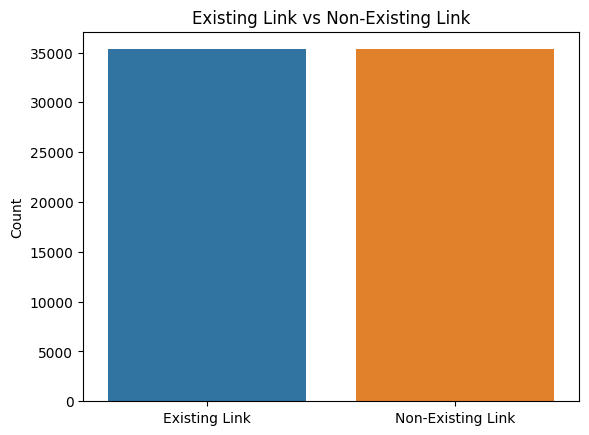

In [ ]:
# @title
# 4. Create a bar chart showing the number of existing vs non-existing edges.
import seaborn as sns
import matplotlib.pyplot as plt

df_samples.groupBy(TARGET_COLUMN).count().show()

follow_group_counts = df_samples.groupBy(TARGET_COLUMN).count().collect()

EXISTING_LABEL = "Existing Link"
NON_EXISTING_LABEL = "Non-Existing Link"

follow_group_labels = [EXISTING_LABEL if r[TARGET_COLUMN] == 1 else NON_EXISTING_LABEL for r in follow_group_counts]

sns.barplot(
    hue=follow_group_labels,
    x=follow_group_labels,
    y=[r["count"] for r in follow_group_counts],
)
plt.title(f"{EXISTING_LABEL} vs {NON_EXISTING_LABEL}")
plt.ylabel("Count")
plt.show()

In [ ]:
# @title
# 6. Compute similarity measures between each node pair in the dataframe using networkX
from pyspark.sql.types import DoubleType

rows = df_samples.collect()

node_pairs = [(r[FROM_COLUMN], r[TO_COLUMN]) for r in rows]

def compute_similarity(similarity_func):
    return {(from_node, to_node): score for from_node, to_node, score in similarity_func(G, node_pairs)}

jaccard_coefficients = compute_similarity(nx.jaccard_coefficient)
adamic_adars = compute_similarity(nx.adamic_adar_index)
preferential_attachments = compute_similarity(nx.preferential_attachment)

features = []
for row in rows:

    from_node, to_node, follow = row[FROM_COLUMN], row[TO_COLUMN], row[TARGET_COLUMN]

    common_neighbors = len(list(nx.common_neighbors(G, from_node, to_node)))

    node_pair = (from_node, to_node)

    jaccard_coefficient = float(jaccard_coefficients[node_pair])
    adamic_adar = float(adamic_adars[node_pair])
    preferential_attachment = preferential_attachments[node_pair]

    features.append((
        from_node,
        to_node,
        common_neighbors,
        jaccard_coefficient,
        adamic_adar,
        preferential_attachment,
        follow))

COMMON_NEIGHBORS_COLUMN = "common_neighbors"
JACCCARD_COEFFICIENT_COLUMN = "jaccard_coefficient"
ADAMIC_ADAR_COLUMN = "adamic_adar"
PREFERENTIAL_ATTACHMENT_COLUMN = "preferential_attachment"

features_schema = StructType([
    StructField(FROM_COLUMN, IntegerType(), False),
    StructField(TO_COLUMN, IntegerType(), False),
    StructField(COMMON_NEIGHBORS_COLUMN, IntegerType(), False),
    StructField(JACCCARD_COEFFICIENT_COLUMN, DoubleType(), False),
    StructField(ADAMIC_ADAR_COLUMN, DoubleType(), False),
    StructField(PREFERENTIAL_ATTACHMENT_COLUMN, IntegerType(), False),
    StructField(TARGET_COLUMN, IntegerType(), False)
])

df_features = spark.createDataFrame(features, features_schema)
df_features.show(5)

+----+----+----------------+-------------------+------------------+-----------------------+----+
|from|  to|common_neighbors|jaccard_coefficient|       adamic_adar|preferential_attachment|link|
+----+----+----------------+-------------------+------------------+-----------------------+----+
|5569| 430|               8|0.04878048780487805|2.0055296869233223|                   7200|   1|
|3530|6222|               0|                0.0|               0.0|                      9|   0|
|4191|  94|               6|0.06521739130434782|1.2672666213883563|                   1776|   1|
| 319|3661|               0|                0.0|               0.0|                     36|   0|
|1482|6789|               0|                0.0|               0.0|                    198|   0|
+----+----+----------------+-------------------+------------------+-----------------------+----+
only showing top 5 rows


In [ ]:
import pandas as pd

pdf = pd.DataFrame(features, columns=[
    FROM_COLUMN,
    TO_COLUMN,
    COMMON_NEIGHBORS_COLUMN,
    JACCCARD_COEFFICIENT_COLUMN,
    ADAMIC_ADAR_COLUMN,
    PREFERENTIAL_ATTACHMENT_COLUMN,
    TARGET_COLUMN,
])

pdf.to_csv("data/twitch_structural.csv", index=False)

## Part 2 — Enrich with Node Attributes

Loads `data/musae_ENGB_target.csv` and adds 5 pairwise features to `data/twitch_structural.csv`, producing `data/twitch.csv`.

In [ ]:
import pandas as pd
import numpy as np

print('Loading data/twitch_structural.csv...')
df = pd.read_csv('data/twitch_structural.csv')
print(f'  Rows: {len(df):,}  Columns: {list(df.columns)}')

print('Loading data/musae_ENGB_target.csv...')
df_target = pd.read_csv('data/musae_ENGB_target.csv').set_index('new_id')
print(f'  Node attribute rows: {len(df_target):,}')

print('Computing pairwise node features...')
views_u   = df['from'].map(lambda n: df_target.loc[n, 'views'])
views_v   = df['to'].map(lambda n:   df_target.loc[n, 'views'])
days_u    = df['from'].map(lambda n: df_target.loc[n, 'days'])
days_v    = df['to'].map(lambda n:   df_target.loc[n, 'days'])
partner_u = df['from'].map(lambda n: int(str(df_target.loc[n, 'partner']) == 'True'))
partner_v = df['to'].map(lambda n:   int(str(df_target.loc[n, 'partner']) == 'True'))
mature_u  = df['from'].map(lambda n: int(str(df_target.loc[n, 'mature'])  == 'True'))
mature_v  = df['to'].map(lambda n:   int(str(df_target.loc[n, 'mature'])  == 'True'))

df['views_diff']   = (views_u - views_v).abs()
df['views_ratio']  = np.minimum(views_u, views_v) / (np.maximum(views_u, views_v) + 1e-9)
df['age_diff']     = (days_u - days_v).abs()
df['same_partner'] = (partner_u == partner_v).astype(int)
df['same_mature']  = (mature_u  == mature_v).astype(int)

df.to_csv('data/twitch.csv', index=False)
print(f'\nSaved data/twitch.csv')
print(f'  Rows:    {len(df):,}')
print(f'  Columns: {list(df.columns)}')


## Part 3 — Verify Dataset

Runs PASS/FAIL checks on `data/twitch.csv`.

In [ ]:
PASS = '  PASS'
FAIL = '  FAIL'

df = pd.read_csv('data/twitch.csv')
errors = 0

def check(name, condition, detail=''):
    global errors
    status = PASS if condition else FAIL
    if not condition:
        errors += 1
    print(f'{status}  {name}' + (f' — {detail}' if detail else ''))

print('=' * 60)
print('Dataset Verification: twitch.csv')
print('=' * 60)

print('\n── Shape ──')
check('Row count is ~70,648', abs(len(df) - 70648) < 100, f'got {len(df):,}')
EXPECTED_COLS = ['from', 'to', 'common_neighbors', 'jaccard_coefficient',
                 'adamic_adar', 'preferential_attachment',
                 'views_diff', 'views_ratio', 'age_diff',
                 'same_partner', 'same_mature', 'link']
check('All 12 columns present', all(c in df.columns for c in EXPECTED_COLS), f'got {list(df.columns)}')

print('\n── Class Balance ──')
vc = df['link'].value_counts()
check('Balanced classes (link=1 == link=0)', vc[1] == vc[0], f'link=1: {vc.get(1,0):,}  link=0: {vc.get(0,0):,}')

print('\n── Missing Values ──')
nulls = df.isnull().sum()
check('No missing values', nulls.sum() == 0, f'{nulls[nulls>0].to_dict()}' if nulls.sum() > 0 else '')

print('\n── Feature Ranges ──')
check('common_neighbors >= 0',          (df.common_neighbors >= 0).all())
check('jaccard_coefficient in [0, 1]',  df.jaccard_coefficient.between(0, 1).all())
check('adamic_adar >= 0',               (df.adamic_adar >= 0).all())
check('preferential_attachment >= 0',   (df.preferential_attachment >= 0).all())
check('views_diff >= 0',                (df.views_diff >= 0).all())
check('views_ratio in [0, 1]',          df.views_ratio.between(0, 1 + 1e-6).all())
check('age_diff >= 0',                  (df.age_diff >= 0).all())
check('same_partner in {0, 1}',         df.same_partner.isin([0, 1]).all())
check('same_mature in {0, 1}',          df.same_mature.isin([0, 1]).all())
check('link in {0, 1}',                 df.link.isin([0, 1]).all())

print('\n── Structural Feature Sanity ──')
check('link=1 higher avg common_neighbors than link=0',
      df[df.link==1].common_neighbors.mean() > df[df.link==0].common_neighbors.mean(),
      f'link=1: {df[df.link==1].common_neighbors.mean():.3f}  link=0: {df[df.link==0].common_neighbors.mean():.3f}')
check('link=1 higher avg adamic_adar than link=0',
      df[df.link==1].adamic_adar.mean() > df[df.link==0].adamic_adar.mean(),
      f'link=1: {df[df.link==1].adamic_adar.mean():.3f}  link=0: {df[df.link==0].adamic_adar.mean():.3f}')
check('link=1 higher avg preferential_attachment than link=0',
      df[df.link==1].preferential_attachment.mean() > df[df.link==0].preferential_attachment.mean(),
      f'link=1: {df[df.link==1].preferential_attachment.mean():.0f}  link=0: {df[df.link==0].preferential_attachment.mean():.0f}')

print('\n── Duplicates ──')
pairs = df[['from', 'to']].apply(lambda r: tuple(sorted([r['from'], r['to']])), axis=1)
check('No duplicate node pairs', pairs.duplicated().sum() == 0,
      f'{pairs.duplicated().sum()} duplicates found' if pairs.duplicated().sum() > 0 else '')

print('\n── Summary Stats ──')
print(f'  Rows:          {len(df):,}')
print(f'  Columns:       {len(df.columns)}')
print(f'  Link=1:        {(df.link==1).sum():,}')
print(f'  Link=0:        {(df.link==0).sum():,}')
print(f'  AA==0 (link=1):{((df.link==1) & (df.adamic_adar==0)).sum():,} '
      f'({((df.link==1) & (df.adamic_adar==0)).mean()*100:.1f}%)')
print(f'  views_ratio mean (link=1): {df[df.link==1].views_ratio.mean():.3f}')
print(f'  views_ratio mean (link=0): {df[df.link==0].views_ratio.mean():.3f}')
print(f'  same_partner rate (link=1): {df[df.link==1].same_partner.mean()*100:.1f}%')
print(f'  same_partner rate (link=0): {df[df.link==0].same_partner.mean()*100:.1f}%')

print('\n' + '=' * 60)
print('ALL CHECKS PASSED' if errors == 0 else f'{errors} CHECK(S) FAILED')
print('=' * 60)
